## Outline
- LLM Inference Fundamentals
- Why LLM Inference is hard?
- Why GPUs sit Idle?
- How vLLM fixes that?
- Hands-on Deployment
- Comparison with other options
- References

## LLM Inference Fundamentals

- What Happens During LLM Inference?
- Prompt Processing (Prefill Phase)
- Token-by-Token Generation (Decode Phase)
- Autoregressive Inference
- Attention Computation During Inference
- KV Cache and Its Role
- Context Window and Memory Growth
- Throughput vs Latency
- Batching and Concurrent Requests
- Key Serving Metrics (TTFT, TPOT, TPS, GPU Utilization)

## Why LLM Inference is hard?

- Inference vs training: different bottlenecks
- Autoregressive token generation
- Prefill and decode phases
- Long context windows and their impact
- KV cache growth
- Memory-bound vs compute-bound workloads
- Throughput, latency, and cost trade-offs
- Challenges of serving millions of requests

## Why GPUs sit Idle?

- Nature of GPU architecture
- Underutilization during decoding
- Inefficient request scheduling
- Variable request lengths
- Memory fragmentation
- Static batching limitations
- Data movement and communication overhead
- Queueing and workload imbalance
- Real-world GPU utilization challenges

## How vLLM fixes that?

### What is vLLM?

vLLM is a fast and easy-to-use library for LLM inference and serving.

### Key contributions or innovations
- Design goals of vLLM
- PagedAttention concept
- Efficient KV cache management
- Continuous batching
- Dynamic scheduling
- Prefix caching
- High-throughput serving architecture
- Multi-GPU support
- Performance improvements over traditional serving

### What is Paged Attention?

### Why do we use it?
- State-of-the-art serving throughput
- Efficient management of attention key and value memory with PagedAttention
- Continuous batching of incoming requests
- Quantization Support
- Support NVIDIA GPUs, AMD CPUs and GPUs, Intel CPUs, Gaudi® accelerators and GPUs, IBM Power CPUs, TPU, and AWS Trainium and Inferentia Accelerators.
- Support for huggingface and open source models

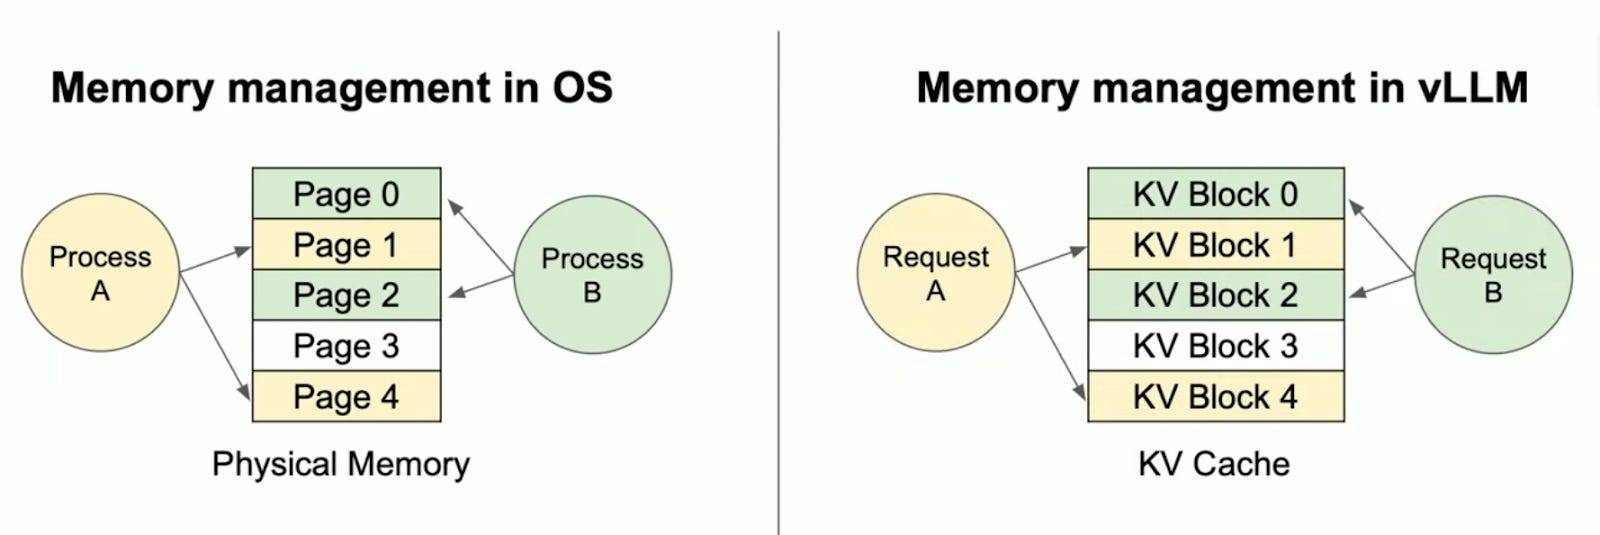

## Hands-on Deployment

- Environment requirements
- Installing vLLM
- Choosing a model
- Launching a vLLM server
- OpenAI-compatible APIs
- Sending inference requests
- Streaming responses
- Serving embedding models
- Basic benchmarking and validation

### Ways to use vLLM
1. Using python library: pip install vLLM
2. Using `vllm serve`: OpenAI-compatible API server for local hosting

### 1. Using Python Library

#### Steps for using vllm hosted LLM - just like transformers library
- Create necessary imports
- Create sampling config for passing custom parameters to LLM
- Do th generation part

In [7]:
!nvidia-smi

zsh:1: command not found: nvidia-smi


In [8]:
!curl -LsSf https://astral.sh/uv/install.sh | sh

downloading uv 0.11.18 aarch64-apple-darwin
installing to /Users/raghunath/.local/bin
  uv
  uvx
everything's installed!


In [9]:
!uv pip uninstall vllm torch torchvision -y

zsh:1: command not found: uv


In [10]:
!uv pip install torchvision

zsh:1: command not found: uv


In [11]:
!uv pip install vllm bitsandbytes --torch-backend=auto

zsh:1: command not found: uv


In [12]:
import vllm
print(vllm.__version__)
print(vllm.__file__)

ModuleNotFoundError: No module named 'vllm'

In [ ]:
# import warnings
from warnings import filterwarnings
filterwarnings('ignore')

In [ ]:
 # import required classes
from vllm import LLM, SamplingParams

# crating samping config
sampling_params = SamplingParams(temperature=0.8, top_p=0.95)

In [ ]:
# llm = LLM(model="Qwen/Qwen2.5-1.5B-Instruct")

In [ ]:
%%writefile test_vllm.py

from vllm import LLM

llm = LLM(
    model="Qwen/Qwen2.5-1.5B-Instruct",
    enforce_eager=True,
)

outputs = llm.generate(
    "San Francisco is a"
)

print(outputs[0].outputs[0].text)

Overwriting test_vllm.py


In [ ]:
!python test_vllm.py

INFO 06-03 13:52:11 [utils.py:278] non-default args: {'disable_log_stats': True, 'enforce_eager': True, 'model': 'Qwen/Qwen2.5-1.5B-Instruct'}
INFO 06-03 13:52:12 [model.py:617] Resolved architecture: Qwen2ForCausalLM
WARNING 06-03 13:52:12 [model.py:2037] Your device 'Tesla T4' (with compute capability 7.5) doesn't support torch.bfloat16. Falling back to torch.float16 for compatibility.
WARNING 06-03 13:52:12 [model.py:2090] Casting torch.bfloat16 to torch.float16.
INFO 06-03 13:52:12 [model.py:1752] Using max model len 32768
INFO 06-03 13:52:12 [scheduler.py:239] Chunked prefill is enabled with max_num_batched_tokens=8192.
INFO 06-03 13:52:12 [vllm.py:977] Asynchronous scheduling is enabled.
WARNING 06-03 13:52:12 [vllm.py:1033] Enforce eager set, disabling torch.compile and CUDAGraphs. This is equivalent to setting -cc.mode=none -cc.cudagraph_mode=none
WARNING 06-03 13:52:12 [vllm.py:1058] Inductor compilation was disabled by user settings, optimizations settings that are only activ

In [ ]:
# check used gpu by model
!nvidia-smi

Wed Jun  3 13:51:52 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   45C    P8             14W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# vllm fetches the LLM weights and required files
# to local, so remove the model to use the space for deploying another model
del llm

In [ ]:
!nvidia-smi

Sun May 31 09:28:16 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!uv pip install bitsandbytes

Using Python 3.12.13 environment at: /usr
Resolved 32 packages in 725ms
Prepared 1 package in 2.99s
Installed 1 package in 2ms
 + bitsandbytes==0.49.2


### 2. Using vllm serve: OpenAI-compatible API server

### Steps to start a server in a Google Colab
- As server needs to run continously, we need to use `colab-xterm` extension. Load it using the below code in Code cell.
```
!pip install colab-xterm -q
%load_ext colabxterm
%xterm
```
- Run the following command to serve any supported model with vLLM.

  Command: `vllm serve Qwen/Qwen2.5-1.5B-Instruct`

- You can run any support model from huggingface provided that you have ample amount of memory to load that model.
- *Approximate* calculation of needed memory:

 $$\text{Total VRAM} \approx \text{Model Weights Memory} + \text{Activation Memory} + \text{KV Cache Memory} + \text{Overhead}$$

  - Model Weights Memory: for a 7B parameters model with FP16 quantization, it is 7B x 2 bytes per param ~ 14 GB
  - Activation Memory: vLLM performs a profile run to accurately measure the peak activation memory. General approximation is 0.25 * Model weights memory

  - KV Cache Memory: Stores intermediate keys and values for previously processed tokens in a sequence. vLLM optimizes this part with `PagedAttention` by only allocating memory (blocks) as needed, instead of reserving a large contiguous chunk.
  - Actual memory depends on model architecture, cache data type, max_num_seqs, max_model_len, etc. Approximate formula is: $$\text{KV Cache per Token} \approx 2 \times \text{Num Layers} \times \text{Hidden Dim} \times \text{Size per Parameter (KV Cache)}$$

  - Overhead memory: It's needed for various system tasks, framework like PyTorch, OS Drivers, etc. Typically it should be at least 1.5 to 3 GB.

Let's say if required memory by weights, activations, and KV Cache is 20GB, then it' safer to use a GPU with at least 24GB of VRAM.

In [ ]:
!pip install colab-xterm -q
%load_ext colabxterm
%xterm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.6/115.6 kB 5.9 MB/s eta 0:00:00


Launching Xterm...

<IPython.core.display.Javascript object>

In [ ]:
!nvidia-smi

Sun May 31 10:36:32 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   75C    P0             31W /   70W |   14277MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# vllm serve Qwen/Qwen2.5-1.5B-Instruct

#### Check deployed model(s) list

In [ ]:
!curl http://localhost:8000/v1/models

{"object":"list","data":[{"id":"Qwen/Qwen2.5-1.5B-Instruct","object":"model","created":1780223465,"owned_by":"vllm","root":"Qwen/Qwen2.5-1.5B-Instruct","parent":null,"max_model_len":32768,"permission":[{"id":"modelperm-8ce896d107a91457","object":"model_permission","created":1780223465,"allow_create_engine":false,"allow_sampling":true,"allow_logprobs":true,"allow_search_indices":false,"allow_view":true,"allow_fine_tuning":false,"organization":"*","group":null,"is_blocking":false}]}]}

#### Generate text by using API Endpoint

In [ ]:
%%bash

curl http://localhost:8000/v1/completions \
  -H "Content-Type: application/json" \
  -d '{
    "model": "Qwen/Qwen2.5-1.5B-Instruct",
    "prompt": "San Francisco is a",
    "max_tokens": 7,
    "temperature": 0
  }'

{"id":"cmpl-b9c147cc4a84b4ee","object":"text_completion","created":1780223559,"model":"Qwen/Qwen2.5-1.5B-Instruct","choices":[{"index":0,"text":" city in the state of California,","logprobs":null,"finish_reason":"length","stop_reason":null,"token_ids":null,"prompt_logprobs":null,"prompt_token_ids":null,"routed_experts":null}],"service_tier":null,"system_fingerprint":"vllm-0.22.0-3ea35257","usage":{"prompt_tokens":4,"total_tokens":11,"completion_tokens":7,"prompt_tokens_details":null},"kv_transfer_params":null}

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   641  100   515  100   126   3559    870 --:--:-- --:--:-- --:--:--  4420


### Programmatically access the hosted LLM

In [ ]:
!pip install openai -q

In [ ]:
from openai import OpenAI

# Modify OpenAI's API key and API base to use vLLM's API server.
openai_api_key = "EMPTY"
openai_api_base = "http://localhost:8000/v1"
client = OpenAI(
    api_key=openai_api_key,
    base_url=openai_api_base,
)
completion = client.completions.create(model="Qwen/Qwen2.5-1.5B-Instruct",
                                      prompt="San Francisco is a")
print("Completion result:", completion.choices[0].text)

Completion result:  city that has seen its fair share of natural disasters. The city was hit hard


## Comparison with other options

vLLM stands out in the LLM serving landscape primarily due to its innovative memory management (Paged Attention) and efficient request scheduling (Continuous Batching). Here's a structured comparison:

| Feature              | vLLM                                    | Hugging Face Transformers (without optimizations) | PyTorch's `torch.compile` / ONNX Runtime / TensorRT | Other LLM Serving Frameworks (e.g., DeepSpeed-MII, TGI) |
| :------------------- | :-------------------------------------- | :------------------------------------------------ | :-------------------------------------------------- | :---------------------------------------------------------- |
| **Memory Management**| Paged Attention (efficient KV cache, dynamic allocation, reduced fragmentation) | Naive KV cache management                         | Focus on kernel optimization, less on KV cache efficiency | Varies, often less optimal than Paged Attention           |
| **Batching**         | Continuous Batching (dynamic, token-level scheduling) | Static Batching                                   | Primarily single-request optimization               | Some dynamic batching, but may suffer from inefficiencies   |
| **Throughput**       | State-of-the-art (high)                 | Low                                               | Moderate (single-request focus)                     | Good, but often surpassed by vLLM under high load         |
| **Latency**          | Low (due to efficient scheduling)       | High                                              | Low (for single requests)                           | Varies                                                      |
| **Scalability**      | Highly scalable for concurrent requests | Limited                                           | Limited for multi-request scaling                   | Moderate to high                                            |
| **GPU Utilization**  | High (maximizes GPU uptime)             | Low (idle time due to static batching)            | High (for single inferences)                        | Varies, can be good but vLLM often achieves higher        |
| **Ease of Use**      | Easy to use and deploy                  | Easy for development, harder for serving            | More complex integration                            | Varies, some can be complex                               |
| **Model Support**    | Wide (Hugging Face, open-source)        | Very wide                                         | Wide (various optimizations)                        | Wide                                                        |
| **Use Case**         | High-throughput serving, production     | Research, development                             | Single-request latency optimization                 | Production serving (but vLLM often superior for throughput) |

**Why vLLM often wins for high-throughput serving:**
vLLM's core innovations directly address the two biggest bottlenecks in LLM serving: inefficient memory usage for the KV cache and wasted GPU cycles due to static batching. By dynamically managing KV cache and continuously filling the GPU with tasks, vLLM achieves state-of-the-art throughput, making it ideal for deploying LLMs in production environments where cost-efficiency and performance are critical.

## References

- vLLM Docs: https://docs.vllm.ai/en/stable/
- vLLM Supported Models: https://docs.vllm.ai/en/v0.10.2/models/supported_models.html
- vLLM GitHub Repo: https://github.com/vllm-project/vllm
- PagedAttention: https://blog.vllm.ai/2023/06/20/vllm.html